In [4]:
# import pandas as pd

# df = pd.read_csv(r"processed_outputs\all_rudder_cases_combined.csv")
# df_prop_off = pd.read_csv(r"AERODYNAMIC_DATA_propoff\propOff.csv")
import pandas as pd

df = pd.read_csv(r"CORRECTIONS_V2\results_propOn_FINAL\propOn_final.csv")
df_prop_off = pd.read_csv(r"CORRECTIONS_V2\results_propOff_FINAL\propOff_final.csv")

T_avg   = 289.977 K
rho_avg = 1.215456 kg/m³
mu_avg  = 1.7981e-05 Pa·s
      V_round          V             Re        CL
775      20.0  19.990762  222966.359083  0.488349
2176     30.0  29.987056  334459.717862  0.494837
3631     40.0  39.986616  445989.506842  0.496582


C:\Users\friso\AppData\Local\Temp\ipykernel_23432\3571825354.py:75: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_re = df_re.groupby("V_round", group_keys=False).apply(pick_row)


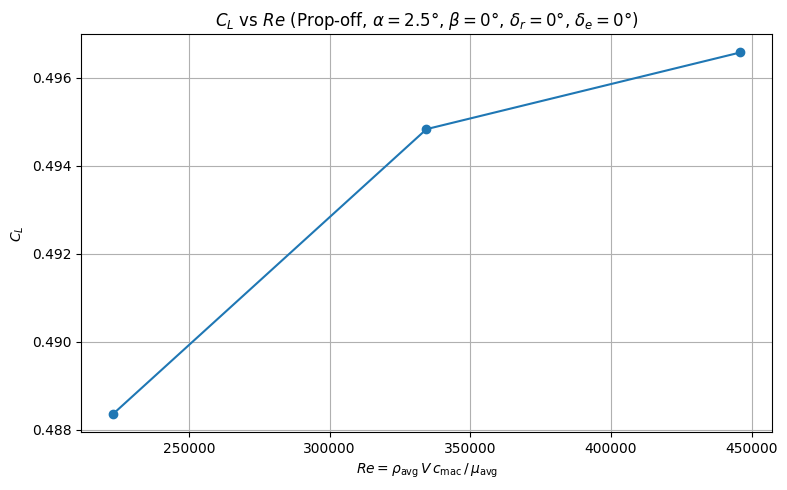

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# --- Sutherland's law ---
mu_ref = 1.716e-5  # Pa·s
T_ref  = 273.15    # K
S      = 110.4     # K

def sutherland_viscosity(T):
    return mu_ref * (T / T_ref)**1.5 * (T_ref + S) / (T + S)

# --- Representative tunnel conditions (averaged from prop-on data) ---
temps = [
    290.81, 290.5, 290.63, 290.71, 290.45, 290.68, 290.57, 290.54, 290.56,
    290.77, 290.76, 290.54, 290.61, 290.53, 290.53, 290.38, 290.77, 290.42,
    290.82, 290.31, 290.83, 290.77, 290.83, 290.59, 290.69, 289.29, 289.89,
    289.33, 289.37, 289.75, 289.05, 289.33, 289.45, 289.41, 289.41, 289.39,
    289.18, 289.41, 289.48, 289.55, 289.09, 289.4,  289.11, 289.29, 289.24,
    289.39, 289.55, 289.31, 289.75, 289.81, 289.23, 289.71, 289.86, 289.23,
    289.85
]
rhos = [
    1.2111837665772662, 1.2124162911880931, 1.211909932667162,
    1.211564445727421,  1.2134526039979827, 1.2123845995887763,
    1.2128315782593753, 1.213028753275484,  1.2129332677003728,
    1.211985376693565,  1.2120390414597149, 1.2130047723183783,
    1.2127125926478157, 1.213034532873517,  1.2130705055473072,
    1.2136371492818563, 1.212021319675703,  1.2134939840084806,
    1.2117650239582876, 1.2139537833203915, 1.211735336730007,
    1.2113024600329465, 1.2110765180038419, 1.21206476484882,
    1.2116478035619338, 1.2185471305276716, 1.2160731113350067,
    1.2183907064735384, 1.2182343256648152, 1.2166486644737404,
    1.2197155774698278, 1.218474990839042,  1.2179096580800357,
    1.2180779880835713, 1.2180659507882505, 1.218162170535493,
    1.2191672579972812, 1.2181261372648537, 1.2178195442593014,
    1.2175010680190128, 1.219558861881395,  1.2181682287001427,
    1.2194624456700003, 1.2186675534126223, 1.2188902649715678,
    1.2182103230444081, 1.2175251309693753, 1.2184869752778251,
    1.2166486644737404, 1.216432841075817,  1.2187878701265824,
    1.216816646064224,  1.2162230099778601, 1.2187999149132185,
    1.2162289133388524
]

T_avg   = np.mean(temps)
rho_avg = np.mean(rhos)
mu_avg  = sutherland_viscosity(T_avg)

print(f"T_avg   = {T_avg:.3f} K")
print(f"rho_avg = {rho_avg:.6f} kg/m³")
print(f"mu_avg  = {mu_avg:.4e} Pa·s")

# --- Wing MAC from manual ---
c_mac = 0.165  # m

# --- Filter prop-off: alpha=2.5, beta=0, rudder=0, elevator=0 ---
df_re = df_prop_off[
    (df_prop_off["AoA_round"] == 2.5) &
    (df_prop_off["AoS_round"] == 0)   &
    (df_prop_off["dR"]        == 0)   &
    (df_prop_off["dE"]        == 0)
].copy()
# Keep only the first sweep (lower original row indices)
df_re = df_re[df_re.index < 8000]

# Re varies through V; rho and mu are fixed representative averages
df_re["Re"] = rho_avg * df_re["V"] * c_mac / mu_avg
df_re = df_re.sort_values("Re")
def pick_row(group):
    v = group["V_round"].iloc[0]
    if v == 30.0:
        return group.iloc[[1]]  # second occurrence
    else:
        return group.iloc[[0]]  # first occurrence

df_re = df_re.groupby("V_round", group_keys=False).apply(pick_row)
print(df_re[["V_round", "V", "Re", "CL"]].to_string())

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df_re["Re"], df_re["CL"], marker="o", linestyle="-")

ax.set_xlabel(r"$Re = \rho_\mathrm{avg} \, V \, c_\mathrm{mac} \, / \, \mu_\mathrm{avg}$")
ax.set_ylabel(r"$C_L$")
ax.set_title(r"$C_L$ vs $Re$ (Prop-off, $\alpha=2.5°$, $\beta=0°$, $\delta_r=0°$, $\delta_e=0°$)")
ax.grid(True)
plt.tight_layout()
plt.savefig("plot_images/CL_vs_Re_propoff_AoA2.5.png", dpi=150)
plt.show()

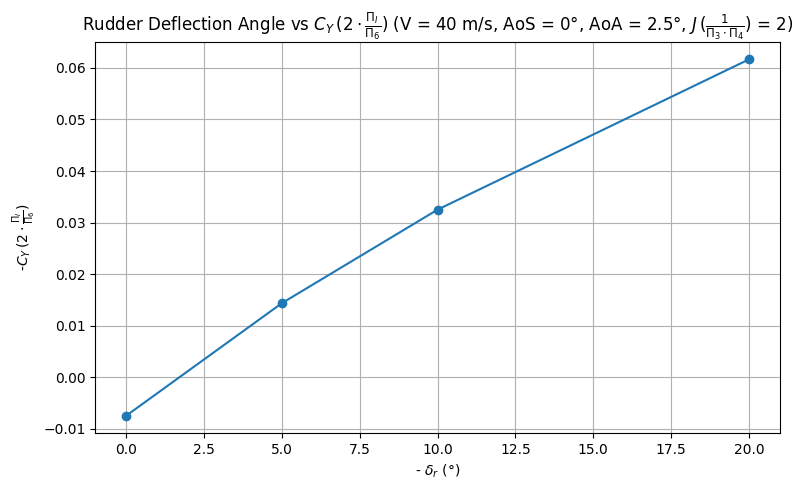

Saved to plot_images/rudder_vs_CY_V40_AoS0_AoA2.5_J2.png


In [70]:
import matplotlib.pyplot as plt

df_filtered = df[(df["V_round"] == 40) & (df["AoS_round"] == 0) & (df["AoA_round"] == 2.5) & (df["J_round"] == 2)]

fig, ax = plt.subplots(figsize=(8, 5))

group_sorted = df_filtered.sort_values("dR")
ax.plot(
    -group_sorted["dR"],
    -group_sorted["CYaw_FINAL"],
    marker="o",
    linestyle="-",
)
ax.set_xlabel(r"- $\delta_r$ (°)")
ax.set_ylabel(r"-$C_Y \, (2 \cdot \frac{\Pi_I}{\Pi_6})$")
ax.set_title(r"Rudder Deflection Angle vs $C_Y \, (2 \cdot \frac{\Pi_I}{\Pi_6})$ (V = 40 m/s, AoS = 0°, AoA = 2.5°, $J \, (\frac{1}{\Pi_3 \cdot \Pi_4})$ = 2)")
ax.grid(True)

plt.tight_layout()
plt.savefig("plot_images/rudder_vs_CY_V40_AoS0_AoA2.5_J2.png", dpi=150)
plt.show()
print("Saved to plot_images/rudder_vs_CY_V40_AoS0_AoA2.5_J2.png")

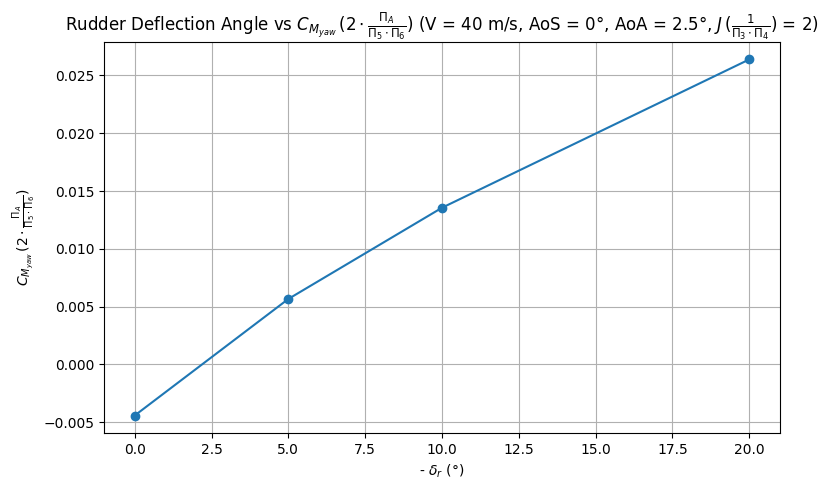

Saved to plot_images/rudder_vs_CMyaw_V40_AoS0_AoA2.5_J2.png


In [71]:
import matplotlib.pyplot as plt

df_filtered = df[(df["V_round"] == 40) & (df["AoS_round"] == 0) & (df["AoA_round"] == 2.5) & (df["J_round"] == 2)]

fig, ax = plt.subplots(figsize=(8, 5))

group_sorted = df_filtered.sort_values("dR")
ax.plot(
    -group_sorted["dR"],
    group_sorted["CMyaw"],
    marker="o",
    linestyle="-",
)
ax.set_xlabel(r"- $\delta_r$ (°)")
ax.set_ylabel(r"$C_{M_{yaw}} \, (2 \cdot \frac{\Pi_A}{\Pi_5 \cdot \Pi_6})$")
ax.set_title(r"Rudder Deflection Angle vs $C_{M_{yaw}} \, (2 \cdot \frac{\Pi_A}{\Pi_5 \cdot \Pi_6})$ (V = 40 m/s, AoS = 0°, AoA = 2.5°, $J \, (\frac{1}{\Pi_3 \cdot \Pi_4})$ = 2)")
ax.grid(True)

plt.tight_layout()
plt.savefig("plot_images/rudder_vs_CMyaw_V40_AoS0_AoA2.5_J2.png", dpi=150)
plt.show()
print("Saved to plot_images/rudder_vs_CMyaw_V40_AoS0_AoA2.5_J2.png")

<>:14: SyntaxWarning: invalid escape sequence '\d'
<>:14: SyntaxWarning: invalid escape sequence '\d'
C:\Users\jules\AppData\Local\Temp\ipykernel_37120\423647516.py:14: SyntaxWarning: invalid escape sequence '\d'
  label=f"$\delta_r$ = {rudder}°",


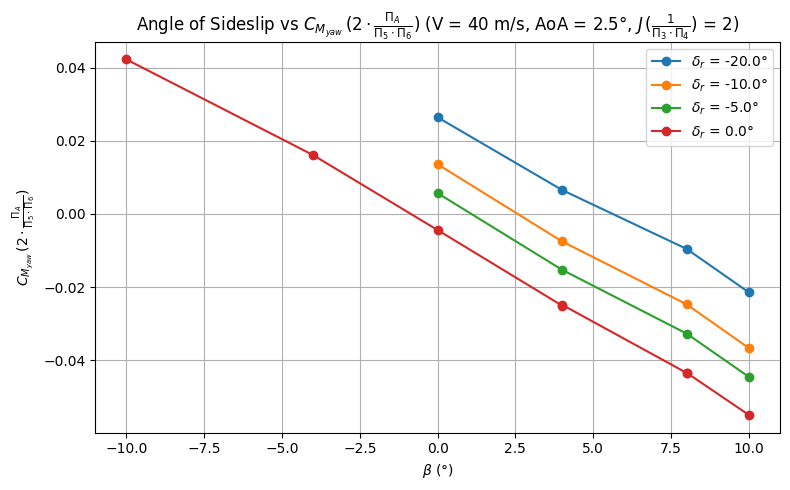

Saved to plot_images/AoS_vs_CMyaw_V40_AoA2.5_J2_all_rudders.png


In [ ]:
import matplotlib.pyplot as plt

df_filtered = df[(df["V_round"] == 40) & (df["AoA_round"] == 2.5) & (df["J_round"] == 2)]

fig, ax = plt.subplots(figsize=(8, 5))

for rudder, group in df_filtered.groupby("dR"):
    group_sorted = group.sort_values("AoS_round")
    ax.plot(
        group_sorted["AoS_round"],
        group_sorted["CMyaw"],
        marker="o",
        linestyle="-",
        label=fr"$\delta_r$ = {rudder}°",
    )

ax.set_xlabel(r"$\beta$ (°)")
ax.set_ylabel(r"$C_{M_{yaw}} \, (2 \cdot \frac{\Pi_A}{\Pi_5 \cdot \Pi_6})$")
ax.set_title(r"Angle of Sideslip vs $C_{M_{yaw}} \, (2 \cdot \frac{\Pi_A}{\Pi_5 \cdot \Pi_6})$ (V = 40 m/s, AoA = 2.5°, $J \, (\frac{1}{\Pi_3 \cdot \Pi_4})$ = 2)")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig("plot_images/AoS_vs_CMyaw_V40_AoA2.5_J2_all_rudders.png", dpi=150)
plt.show()
print("Saved to plot_images/AoS_vs_CMyaw_V40_AoA2.5_J2_all_rudders.png")


<>:89: SyntaxWarning: invalid escape sequence '\d'
<>:89: SyntaxWarning: invalid escape sequence '\d'
C:\Users\jules\AppData\Local\Temp\ipykernel_37120\425872192.py:89: SyntaxWarning: invalid escape sequence '\d'
  label="Prop-off $\delta_r$=0°"


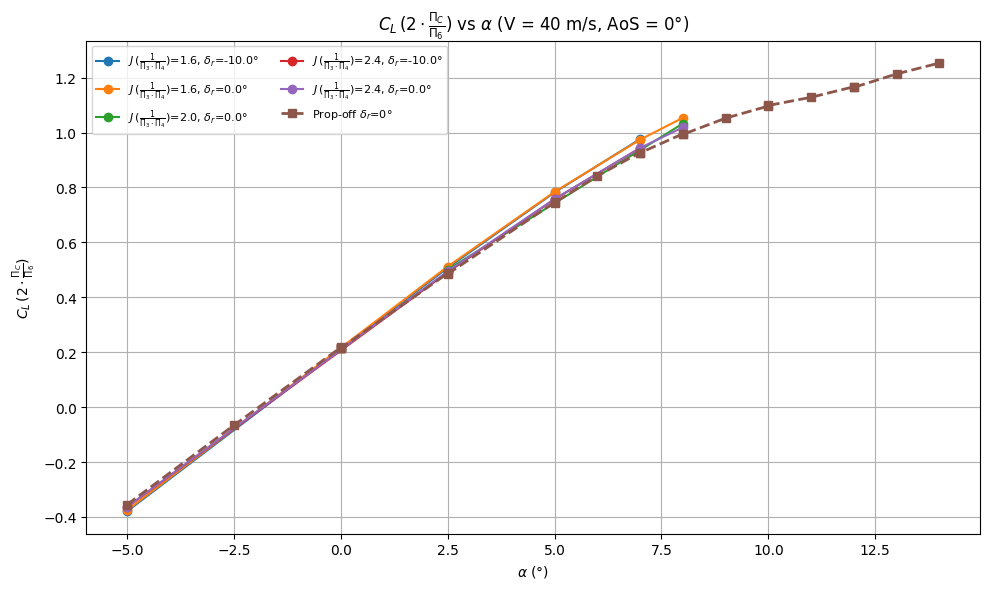

Saved to plot_images/CL_vs_alpha_V40_AoS0_all_J_rudders_with_propoff.png


In [77]:
import os
import matplotlib.pyplot as plt

# Make sure output folder exists
os.makedirs("plot_images", exist_ok=True)

# -----------------------------------
# Create rounded columns if missing
# -----------------------------------
if "V_round" not in df.columns:
    df["V_round"] = df["V"].round()

if "AoS_round" not in df.columns:
    df["AoS_round"] = df["AoS"].round()

if "AoA_round" not in df.columns:
    df["AoA_round"] = df["AoA"].round(1)

if "V_round" not in df_prop_off.columns:
    df_prop_off["V_round"] = df_prop_off["V"].round()

if "AoS_round" not in df_prop_off.columns:
    df_prop_off["AoS_round"] = df_prop_off["AoS"].round()

if "AoA_round" not in df_prop_off.columns:
    df_prop_off["AoA_round"] = df_prop_off["AoA"].round(1)

# -----------------------------------
# Filter prop-on data
# -----------------------------------
df_filtered = df[
    (df["V_round"] == 40) &
    (df["AoS_round"] == 0)
].copy()

# -----------------------------------
# Filter prop-off data
# Here also choosing dR = 0 and dE = 0
# -----------------------------------
df_prop_off_filtered = df_prop_off[
    (df_prop_off["V_round"] == 40) &
    (df_prop_off["AoS_round"] == 0) &
    (df_prop_off["dR"] == 0) &
    (df_prop_off["dE"] == 0)
].copy()

# Keep only prop-on groups with more than one unique AoA value
valid_groups = (
    df_filtered.groupby(["J_round", "dR"])["AoA_round"]
    .nunique()
    .reset_index()
)
valid_groups = valid_groups[valid_groups["AoA_round"] > 1]

# Sort prop-off data by AoA
df_prop_off_filtered = df_prop_off_filtered.sort_values("AoA_round")

# -----------------------------------
# Plot
# -----------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

# Plot all prop-on curves
for _, row in valid_groups.iterrows():
    j_val = row["J_round"]
    rudder_val = row["dR"]

    group = df_filtered[
        (df_filtered["J_round"] == j_val) &
        (df_filtered["dR"] == rudder_val)
    ].sort_values("AoA_round")

    ax.plot(
        group["AoA_round"],
        group["CL_FINAL"],
        marker="o",
        linestyle="-",
        label=fr"$J \, (\frac{{1}}{{\Pi_3 \cdot \Pi_4}})$={j_val}, $\delta_r$={rudder_val}°"
    )

# Plot prop-off curve
if not df_prop_off_filtered.empty:
    ax.plot(
        df_prop_off_filtered["AoA_round"],
        df_prop_off_filtered["CL_FINAL"],
        marker="s",
        linestyle="--",
        linewidth=2,
        label="Prop-off $\delta_r$=0°"
    )
else:
    print("Warning: no matching prop-off data found.")

# Labels and styling
ax.set_xlabel(r"$\alpha$ (°)")
ax.set_ylabel(r"$C_L \, (2 \cdot \frac{\Pi_C}{\Pi_6})$")
ax.set_title(r"$C_L \, (2 \cdot \frac{\Pi_C}{\Pi_6})$ vs $\alpha$ (V = 40 m/s, AoS = 0°)")
ax.legend(fontsize=8, ncol=2)
ax.grid(True)

# Save and show
save_path = "plot_images/CL_vs_alpha_V40_AoS0_all_J_rudders_with_propoff.png"
plt.tight_layout()
plt.savefig(save_path, dpi=150)
plt.show()

print(f"Saved to {save_path}")

<>:89: SyntaxWarning: invalid escape sequence '\d'
<>:89: SyntaxWarning: invalid escape sequence '\d'
C:\Users\jules\AppData\Local\Temp\ipykernel_37120\826976185.py:89: SyntaxWarning: invalid escape sequence '\d'
  label="Prop-off $\delta_r$=0°"


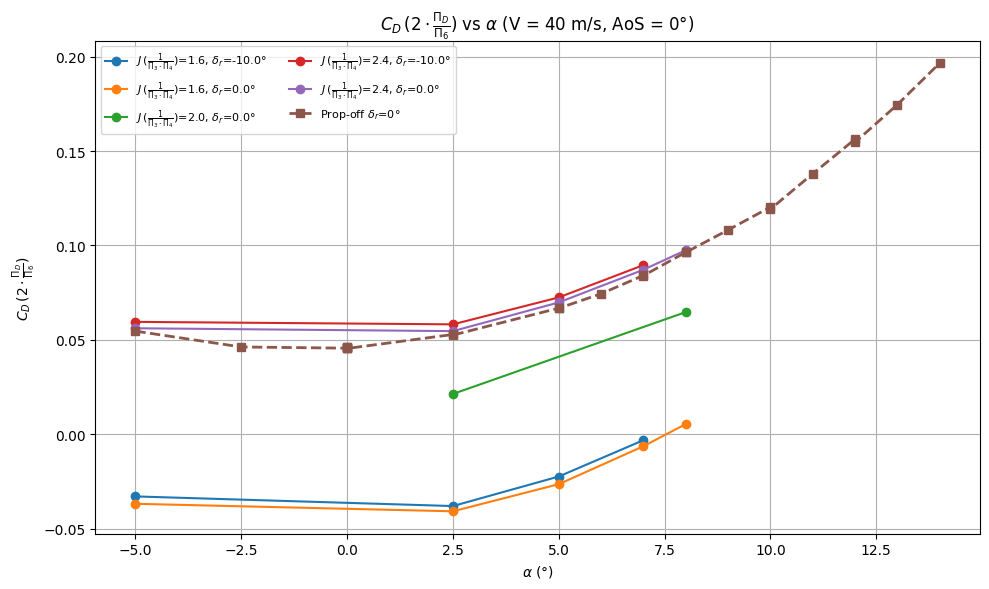

Saved to plot_images/CD_vs_alpha_V40_AoS0_all_J_rudders_with_propoff.png


In [78]:
import os
import matplotlib.pyplot as plt

# Make sure output folder exists
os.makedirs("plot_images", exist_ok=True)

# -----------------------------------
# Create rounded columns if missing
# -----------------------------------
if "V_round" not in df.columns:
    df["V_round"] = df["V"].round()

if "AoS_round" not in df.columns:
    df["AoS_round"] = df["AoS"].round()

if "AoA_round" not in df.columns:
    df["AoA_round"] = df["AoA"].round(1)

if "V_round" not in df_prop_off.columns:
    df_prop_off["V_round"] = df_prop_off["V"].round()

if "AoS_round" not in df_prop_off.columns:
    df_prop_off["AoS_round"] = df_prop_off["AoS"].round()

if "AoA_round" not in df_prop_off.columns:
    df_prop_off["AoA_round"] = df_prop_off["AoA"].round(1)

# -----------------------------------
# Filter prop-on data
# -----------------------------------
df_filtered = df[
    (df["V_round"] == 40) &
    (df["AoS_round"] == 0)
].copy()

# -----------------------------------
# Filter prop-off data
# Here choosing dR = 0 and dE = 0
# -----------------------------------
df_prop_off_filtered = df_prop_off[
    (df_prop_off["V_round"] == 40) &
    (df_prop_off["AoS_round"] == 0) &
    (df_prop_off["dR"] == 0) &
    (df_prop_off["dE"] == 0)
].copy()

# Keep only prop-on groups with more than one unique AoA value
valid_groups = (
    df_filtered.groupby(["J_round", "dR"])["AoA_round"]
    .nunique()
    .reset_index()
)
valid_groups = valid_groups[valid_groups["AoA_round"] > 1]

# Sort prop-off data by AoA
df_prop_off_filtered = df_prop_off_filtered.sort_values("AoA_round")

# -----------------------------------
# Plot
# -----------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

# Plot all prop-on curves
for _, row in valid_groups.iterrows():
    j_val = row["J_round"]
    rudder_val = row["dR"]

    group = df_filtered[
        (df_filtered["J_round"] == j_val) &
        (df_filtered["dR"] == rudder_val)
    ].sort_values("AoA_round")

    ax.plot(
        group["AoA_round"],
        group["CD_FINAL"],
        marker="o",
        linestyle="-",
        label=fr"$J \, (\frac{{1}}{{\Pi_3 \cdot \Pi_4}})$={j_val}, $\delta_r$={rudder_val}°"
    )

# Plot prop-off curve
if not df_prop_off_filtered.empty:
    ax.plot(
        df_prop_off_filtered["AoA_round"],
        df_prop_off_filtered["CD_FINAL"],
        marker="s",
        linestyle="--",
        linewidth=2,
        label="Prop-off $\delta_r$=0°"
    )
else:
    print("Warning: no matching prop-off data found.")

# Labels and styling
ax.set_xlabel(r"$\alpha$ (°)")
ax.set_ylabel(r"$C_D \, (2 \cdot \frac{\Pi_D}{\Pi_6})$")
ax.set_title(r"$C_D \, (2 \cdot \frac{\Pi_D}{\Pi_6})$ vs $\alpha$ (V = 40 m/s, AoS = 0°)")
ax.legend(fontsize=8, ncol=2)
ax.grid(True)

# Save and show
save_path = "plot_images/CD_vs_alpha_V40_AoS0_all_J_rudders_with_propoff.png"
plt.tight_layout()
plt.savefig(save_path, dpi=150)
plt.show()

print(f"Saved to {save_path}")


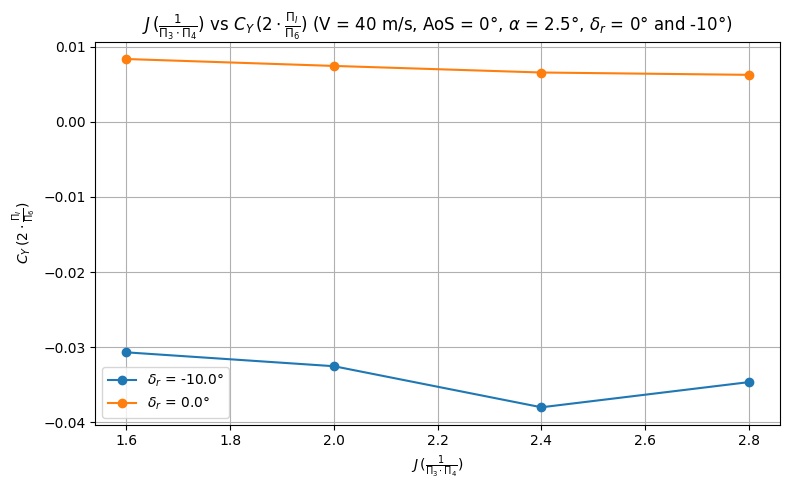

Saved to plot_images/J_vs_CY_V40_AoS0_AoA2.5_rudder0_m10.png


In [79]:
import matplotlib.pyplot as plt

df_filtered = df[
    (df["V_round"] == 40) &
    (df["AoS_round"] == 0) &
    (df["AoA_round"] == 2.5) &
    (df["dR"].isin([0, -10]))
]

fig, ax = plt.subplots(figsize=(8, 5))

for rudder_val, group in df_filtered.groupby("dR"):
    group_sorted = group.sort_values("J_round")
    ax.plot(
        group_sorted["J_round"],
        group_sorted["CYaw_FINAL"],
        marker="o",
        linestyle="-",
        label=fr"$\delta_r$ = {rudder_val}°",
    )

ax.set_xlabel(r"$J \, (\frac{1}{\Pi_3 \cdot \Pi_4})$")
ax.set_ylabel(r"$C_Y \, (2 \cdot \frac{\Pi_I}{\Pi_6})$")
ax.set_title(r"$J \, (\frac{1}{\Pi_3 \cdot \Pi_4})$ vs $C_Y \, (2 \cdot \frac{\Pi_I}{\Pi_6})$ (V = 40 m/s, AoS = 0°, $\alpha$ = 2.5°, $\delta_r$ = 0° and -10°)")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig("plot_images/J_vs_CY_V40_AoS0_AoA2.5_rudder0_m10.png", dpi=150)
plt.show()
print("Saved to plot_images/J_vs_CY_V40_AoS0_AoA2.5_rudder0_m10.png")


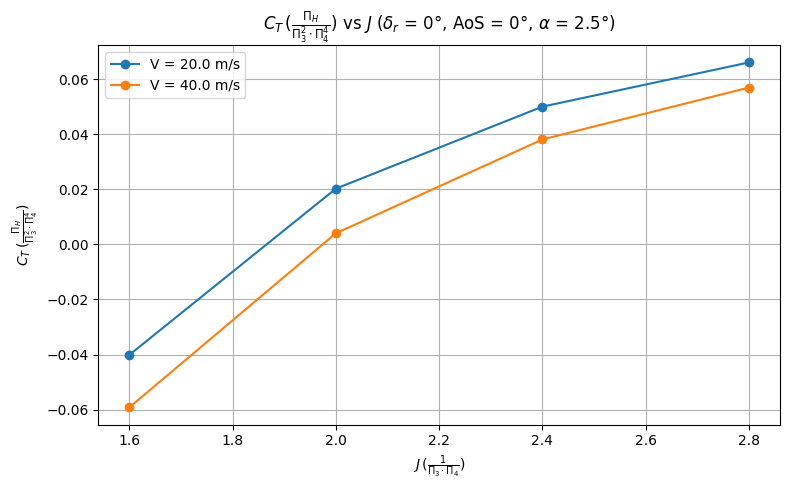

Saved to plot_images/CT_vs_J_V20_V40_AoS0_AoA2.5_rudder0.png


In [80]:
import matplotlib.pyplot as plt

df_filtered = df[
    (df["V_round"].isin([20, 40])) &
    (df["AoS_round"] == 0) &
    (df["AoA_round"] == 2.5) &
    (df["dR"] == 0)
]

fig, ax = plt.subplots(figsize=(8, 5))

for v_val, group in df_filtered.groupby("V_round"):
    group_sorted = group.sort_values("J_round")
    ax.plot(
        group_sorted["J_round"],
        group_sorted["CT"],
        marker="o",
        linestyle="-",
        label=f"V = {v_val} m/s",
    )

ax.set_xlabel(r"$J \, (\frac{1}{\Pi_3 \cdot \Pi_4})$")
ax.set_ylabel(r"$C_T \, (\frac{\Pi_H}{\Pi_3^2 \cdot \Pi_4^4})$")
ax.set_title(r"$C_T \, (\frac{\Pi_H}{\Pi_3^2 \cdot \Pi_4^4})$ vs $J$ ($\delta_r$ = 0°, AoS = 0°, $\alpha$ = 2.5°)")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig("plot_images/CT_vs_J_V20_V40_AoS0_AoA2.5_rudder0.png", dpi=150)
plt.show()
print("Saved to plot_images/CT_vs_J_V20_V40_AoS0_AoA2.5_rudder0.png")


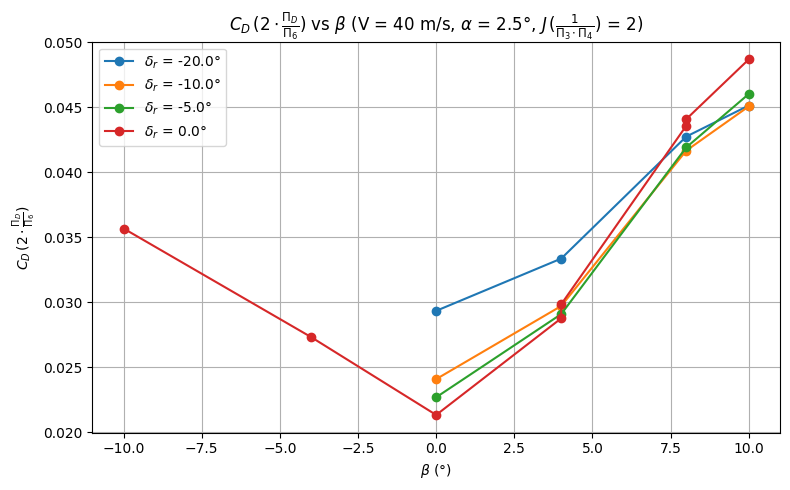

Saved to plot_images/CD_vs_AoS_V40_AoA2.5_J2_all_rudders.png


In [81]:
import matplotlib.pyplot as plt

df_filtered = df[
    (df["V_round"] == 40) &
    (df["AoA_round"] == 2.5) &
    (df["J_round"] == 2)
]

fig, ax = plt.subplots(figsize=(8, 5))

for rudder_val, group in df_filtered.groupby("dR"):
    group_sorted = group.sort_values("AoS_round")
    ax.plot(
        group_sorted["AoS_round"],
        group_sorted["CD_FINAL"],
        marker="o",
        linestyle="-",
        label=fr"$\delta_r$ = {rudder_val}°",
    )

ax.set_xlabel(r"$\beta$ (°)")
ax.set_ylabel(r"$C_D \, (2 \cdot \frac{\Pi_D}{\Pi_6})$")
ax.set_title(r"$C_D \, (2 \cdot \frac{\Pi_D}{\Pi_6})$ vs $\beta$ (V = 40 m/s, $\alpha$ = 2.5°, $J \, (\frac{1}{\Pi_3 \cdot \Pi_4})$ = 2)")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig("plot_images/CD_vs_AoS_V40_AoA2.5_J2_all_rudders.png", dpi=150)
plt.show()
print("Saved to plot_images/CD_vs_AoS_V40_AoA2.5_J2_all_rudders.png")


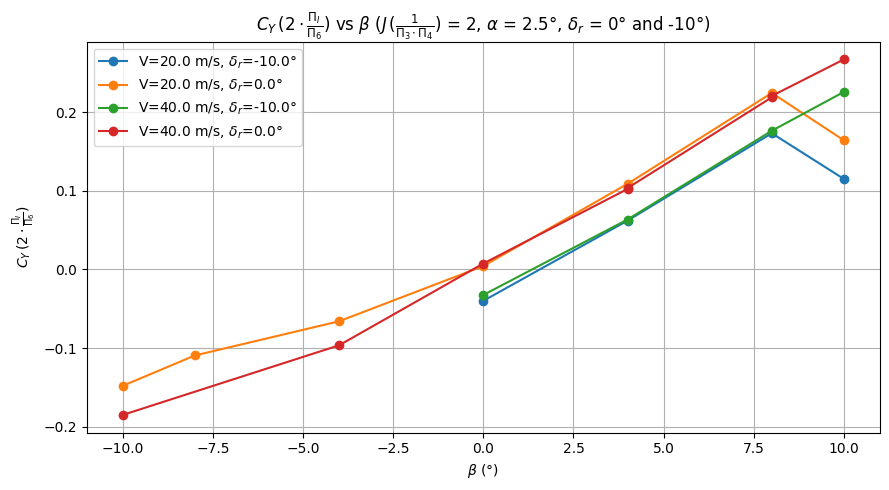

Saved to plot_images/CY_vs_AoS_V20_V40_rudder0_m10_J2_AoA2.5.png


In [82]:
import matplotlib.pyplot as plt

df_filtered = df[
    (df["V_round"].isin([20, 40])) &
    (df["dR"].isin([0, -10])) &
    (df["J_round"] == 2) &
    (df["AoA_round"] == 2.5)
]

fig, ax = plt.subplots(figsize=(9, 5))

for (v_val, rudder_val), group in df_filtered.groupby(["V_round", "dR"]):
    group_sorted = group.sort_values("AoS_round")
    ax.plot(
        group_sorted["AoS_round"],
        group_sorted["CYaw_FINAL"],
        marker="o",
        linestyle="-",
        label=fr"V={v_val} m/s, $\delta_r$={rudder_val}°",
    )

ax.set_xlabel(r"$\beta$ (°)")
ax.set_ylabel(r"$C_Y \, (2 \cdot \frac{\Pi_I}{\Pi_6})$")
ax.set_title(r"$C_Y \, (2 \cdot \frac{\Pi_I}{\Pi_6})$ vs $\beta$ ($J \, (\frac{1}{\Pi_3 \cdot \Pi_4})$ = 2, $\alpha$ = 2.5°, $\delta_r$ = 0° and -10°)")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig("plot_images/CY_vs_AoS_V20_V40_rudder0_m10_J2_AoA2.5.png", dpi=150)
plt.show()
print("Saved to plot_images/CY_vs_AoS_V20_V40_rudder0_m10_J2_AoA2.5.png")


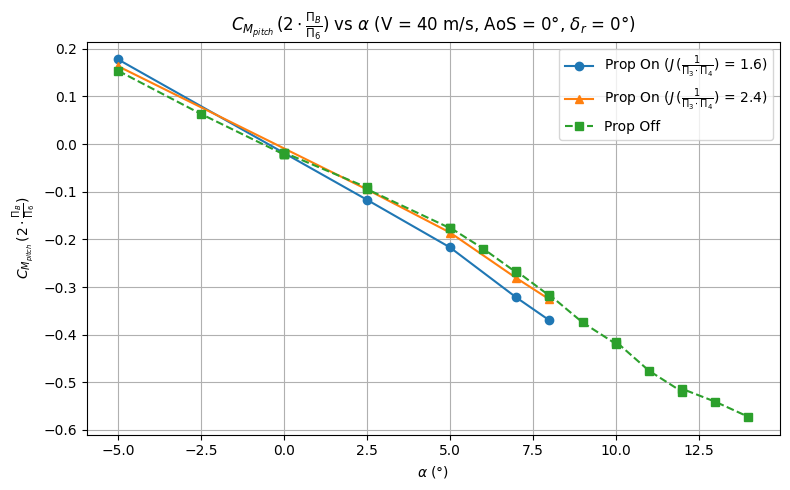

Saved to plot_images/CMpitch_vs_alpha_V40_AoS0_rudder0.png


In [88]:
import matplotlib.pyplot as plt

# Filter prop on J=1.6
df_on_filtered_16 = df[
    (df["V_round"] == 40) & 
    (df["AoS_round"] == 0) & 
    (df["dR"] == 0) & 
    (df["J_round"] == 1.6)
].sort_values("AoA_round")

# Filter prop on J=2.4
df_on_filtered_24 = df[
    (df["V_round"] == 40) & 
    (df["AoS_round"] == 0) & 
    (df["dR"] == 0) & 
    (df["J_round"] == 2.4)
].sort_values("AoA_round")

# Filter prop off
df_off_filtered = df_prop_off[
    (round(df_prop_off["V"]) == 40) & 
    (round(df_prop_off["AoS"]) == 0) & 
    (df_prop_off["dE"] == 0) &
    (df_prop_off["dR"] == 0)
].sort_values("AoA")

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    df_on_filtered_16["AoA_round"],
    df_on_filtered_16["CMpitch_FINAL"],
    marker="o",
    linestyle="-",
        label=r"Prop On ($J \, (\frac{1}{\Pi_3 \cdot \Pi_4})$ = 1.6)"
    )

ax.plot(
    df_on_filtered_24["AoA_round"],
    df_on_filtered_24["CMpitch_FINAL"],
    marker="^",
    linestyle="-",
    label=r"Prop On ($J \, (\frac{1}{\Pi_3 \cdot \Pi_4})$ = 2.4)"
)

ax.plot(
    df_off_filtered["AoA"],
    df_off_filtered["CMpitch_FINAL"],
    marker="s",
    linestyle="--",
    label="Prop Off"
)

ax.set_xlabel(r"$\alpha$ (°)")
ax.set_ylabel(r"$C_{M_{pitch}} \, (2 \cdot \frac{\Pi_B}{\Pi_6})$")
ax.set_title(r"$C_{M_{pitch}} \, (2 \cdot \frac{\Pi_B}{\Pi_6})$ vs $\alpha$ (V = 40 m/s, AoS = 0°, $\delta_r$ = 0°)")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig("plot_images/CMpitch_vs_alpha_V40_AoS0_rudder0.png", dpi=150)
plt.show()
print("Saved to plot_images/CMpitch_vs_alpha_V40_AoS0_rudder0.png")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Sutherland's law ---
mu_ref = 1.716e-5  # Pa·s
T_ref  = 273.15    # K
S      = 110.4     # K

def sutherland_viscosity(T):
    return mu_ref * (T / T_ref)**1.5 * (T_ref + S) / (T + S)

# --- Representative tunnel conditions (averaged from prop-on data) ---
temps = [
    290.81, 290.5, 290.63, 290.71, 290.45, 290.68, 290.57, 290.54, 290.56,
    290.77, 290.76, 290.54, 290.61, 290.53, 290.53, 290.38, 290.77, 290.42,
    290.82, 290.31, 290.83, 290.77, 290.83, 290.59, 290.69, 289.29, 289.89,
    289.33, 289.37, 289.75, 289.05, 289.33, 289.45, 289.41, 289.41, 289.39,
    289.18, 289.41, 289.48, 289.55, 289.09, 289.4,  289.11, 289.29, 289.24,
    289.39, 289.55, 289.31, 289.75, 289.81, 289.23, 289.71, 289.86, 289.23,
    289.85
]
rhos = [
    1.2111837665772662, 1.2124162911880931, 1.211909932667162,
    1.211564445727421,  1.2134526039979827, 1.2123845995887763,
    1.2128315782593753, 1.213028753275484,  1.2129332677003728,
    1.211985376693565,  1.2120390414597149, 1.2130047723183783,
    1.2127125926478157, 1.213034532873517,  1.2130705055473072,
    1.2136371492818563, 1.212021319675703,  1.2134939840084806,
    1.2117650239582876, 1.2139537833203915, 1.211735336730007,
    1.2113024600329465, 1.2110765180038419, 1.21206476484882,
    1.2116478035619338, 1.2185471305276716, 1.2160731113350067,
    1.2183907064735384, 1.2182343256648152, 1.2166486644737404,
    1.2197155774698278, 1.218474990839042,  1.2179096580800357,
    1.2180779880835713, 1.2180659507882505, 1.218162170535493,
    1.2191672579972812, 1.2181261372648537, 1.2178195442593014,
    1.2175010680190128, 1.219558861881395,  1.2181682287001427,
    1.2194624456700003, 1.2186675534126223, 1.2188902649715678,
    1.2182103230444081, 1.2175251309693753, 1.2184869752778251,
    1.2166486644737404, 1.216432841075817,  1.2187878701265824,
    1.216816646064224,  1.2162230099778601, 1.2187999149132185,
    1.2162289133388524
]

T_avg   = np.mean(temps)
rho_avg = np.mean(rhos)
mu_avg  = sutherland_viscosity(T_avg)

print(f"T_avg   = {T_avg:.3f} K")
print(f"rho_avg = {rho_avg:.6f} kg/m³")
print(f"mu_avg  = {mu_avg:.4e} Pa·s")

# --- Wing MAC from manual ---
c_mac = 0.165  # m

# --- Filter prop-off: alpha=2.5, beta=0, rudder=0, elevator=0 ---
df_re = df_prop_off[
    (df_prop_off["AoA_round"] == 2.5) &
    (df_prop_off["AoS_round"] == 0)   &
    (df_prop_off["dR"]        == 0)   &
    (df_prop_off["dE"]        == 0)
].copy()
# Keep only the first sweep (lower original row indices)
df_re = df_re[df_re.index < 500]

# Re varies through V; rho and mu are fixed representative averages
df_re["Re"] = rho_avg * df_re["V"] * c_mac / mu_avg
df_re = df_re.sort_values("Re")

print(df_re[["V_round", "V", "Re", "CL_FINAL"]].to_string())

# --- Plot ---
# fig, ax = plt.subplots(figsize=(8, 5))
# ax.plot(df_re["Re"], df_re["CL_FINAL"], marker="o", linestyle="-")

# ax.set_xlabel(r"$Re \, (\Pi_1^{-1}) = \rho_\mathrm{avg} \, V \, c_\mathrm{mac} \, / \, \mu_\mathrm{avg}$")
# ax.set_ylabel(r"$C_L \, (2 \cdot \frac{\Pi_C}{\Pi_6})$")
# ax.set_title(r"$C_L \, (2 \cdot \frac{\Pi_C}{\Pi_6})$ vs $Re \, (\Pi_1^{-1})$ (Prop-off, $\alpha=2.5°$, $\beta=0°$, $\delta_r=0°$, $\delta_e=0°$)")
# ax.grid(True)
# plt.tight_layout()
# plt.savefig("plot_images/CL_vs_Re_propoff_AoA2.5.png", dpi=150)
# plt.show()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(df_re["Re"], df_re["CL_FINAL"], marker="o", linestyle="-")
ax1.set_xlabel(r"$Re \, (\Pi_1^{-1}) = \rho_\mathrm{avg} \, V \, c_\mathrm{mac} \, / \, \mu_\mathrm{avg}$")
ax1.set_ylabel(r"$C_L \, (2 \cdot \frac{\Pi_C}{\Pi_6})$")
ax1.set_title(r"$C_L \, (2 \cdot \frac{\Pi_C}{\Pi_6})$ vs $Re \, (\Pi_1^{-1})$")
ax1.grid(True)

ax2.plot(df_re["Re"], df_re["CD_FINAL"], marker="o", linestyle="-")
ax2.set_xlabel(r"$Re \, (\Pi_1^{-1}) = \rho_\mathrm{avg} \, V \, c_\mathrm{mac} \, / \, \mu_\mathrm{avg}$")
ax2.set_ylabel(r"$C_D \, (2 \cdot \frac{\Pi_D}{\Pi_6})$")
ax2.set_title(r"$C_D \, (2 \cdot \frac{\Pi_D}{\Pi_6})$ vs $Re \, (\Pi_1^{-1})$")
ax2.grid(True)

fig.suptitle(r"Prop-off, $\alpha=2.5°$, $\beta=0°$, $\delta_r=0°$, $\delta_e=0°$")
plt.tight_layout()
plt.savefig("plot_images/CL_CD_vs_Re_propoff_AoA2.5.png", dpi=150)
plt.show()

T_avg   = 289.977 K
rho_avg = 1.215456 kg/m³
mu_avg  = 1.7981e-05 Pa·s


NameError: name 'df_prop_off' is not defined

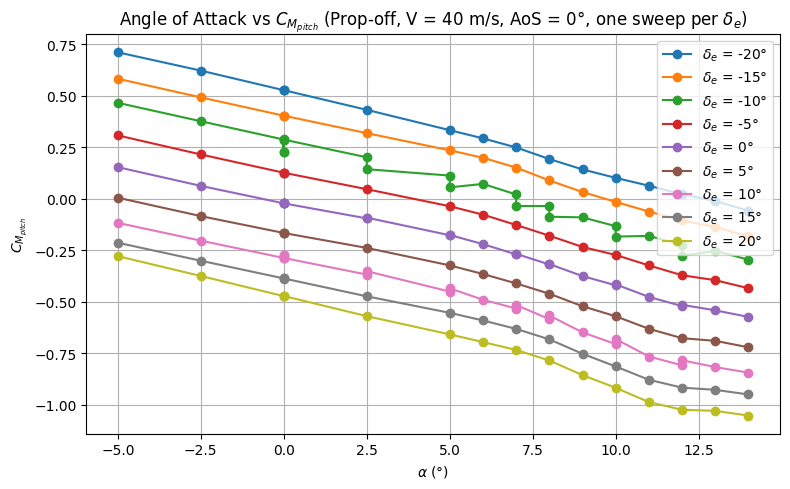

In [ ]:
import os
import matplotlib.pyplot as plt
import pandas as pd

os.makedirs("plot_images", exist_ok=True)

# Create rounded columns if missing
if "V_round" not in df_prop_off.columns:
    df_prop_off["V_round"] = df_prop_off["V"].round()

if "AoS_round" not in df_prop_off.columns:
    df_prop_off["AoS_round"] = df_prop_off["AoS"].round()

if "AoA_round" not in df_prop_off.columns:
    df_prop_off["AoA_round"] = df_prop_off["AoA"].round(1)

# Base filter
df_filtered = df_prop_off[
    (df_prop_off["V_round"] == 40) &
    (df_prop_off["AoS_round"] == 0) &
    (df_prop_off["dR"] == 0)
].copy()

# Keep original row index
df_filtered = df_filtered.sort_index()

def select_best_sweep(group, gap_threshold=100):
    """
    Split one dE group into separate sweeps based on jumps in original row index.
    Keep the sweep with the largest AoA range.
    If tied, keep the one with the most data points.
    """
    group = group.sort_index().copy()

    # Split into sweep blocks when row jump is large
    row_jump = group.index.to_series().diff().fillna(0)
    group["sweep_id"] = (row_jump > gap_threshold).cumsum()

    best_block = None
    best_range = -1
    best_npoints = -1

    for _, block in group.groupby("sweep_id"):
        aoa_range = block["AoA"].max() - block["AoA"].min()
        npoints = len(block)

        if (aoa_range > best_range) or (aoa_range == best_range and npoints > best_npoints):
            best_block = block.copy()
            best_range = aoa_range
            best_npoints = npoints

    return best_block

# Create figure
fig, ax = plt.subplots(figsize=(8, 5))

selected_sweeps = {}

# Plot one cleaned sweep for each elevator deflection
for de, group in df_filtered.groupby("dE"):
    best_sweep = select_best_sweep(group, gap_threshold=100)
    best_sweep = best_sweep.sort_values("AoA_round")

    selected_sweeps[de] = best_sweep.copy()

    ax.plot(
        best_sweep["AoA_round"],
        best_sweep["CMpitch_FINAL"],
        marker="o",
        linestyle="-",
        label=fr"$\delta_e$ = {de}°",
    )

ax.set_xlabel(r"$\alpha$ (°)")
ax.set_ylabel(r"$C_{M_{pitch}} \, (2 \cdot \frac{\Pi_B}{\Pi_6})$")
ax.set_title(r"Angle of Attack vs $C_{M_{pitch}} \, (2 \cdot \frac{\Pi_B}{\Pi_6})$ (Prop-off, V = 40 m/s, AoS = 0°, one sweep per $\delta_e$)")
ax.legend()
ax.grid(True)

plt.tight_layout()
save_path = "plot_images/AoA_vs_CMpitch_propoff_V40_AoS0_all_elevators_cleaned.png"
plt.savefig(save_path, dpi=150)
plt.show()

# print(f"Saved to {save_path}")

# Optional: print summary of chosen sweeps
# print("\nChosen sweep per elevator deflection:")
# for de, sweep in selected_sweeps.items():
#     print(
#         f"dE = {de:>5}: rows {sweep.index.min()+2} to {sweep.index.max()+2}, "
#         f"AoA range = {sweep['AoA'].min():.3f} to {sweep['AoA'].max():.3f}, "
#         f"points = {len(sweep)}"
#     )


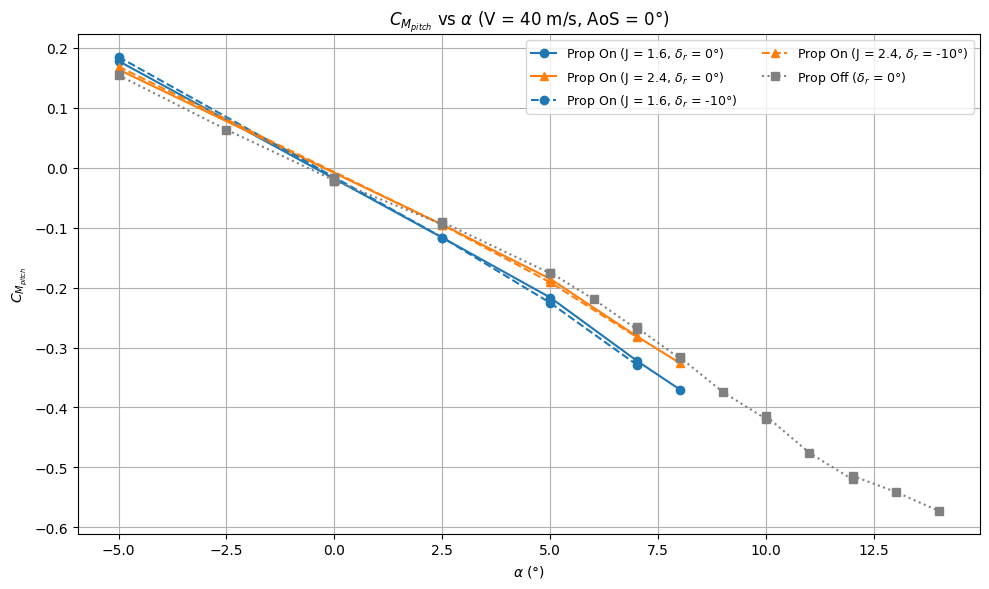

Saved to plot_images/CMpitch_vs_alpha_V40_AoS0_rudder0_m10.png


In [ ]:
import matplotlib.pyplot as plt

def select_best_sweep(group, gap_threshold=100):
    if group is None or group.empty:
        return group
    
    group = group.sort_index().copy()
    row_jump = group.index.to_series().diff().fillna(0)
    group["sweep_id"] = (row_jump > gap_threshold).cumsum()

    best_block = None
    best_range = -1
    best_npoints = -1

    for _, block in group.groupby("sweep_id"):
        aoa_range = block["AoA"].max() - block["AoA"].min()
        npoints = len(block)

        if (aoa_range > best_range) or (aoa_range == best_range and npoints > best_npoints):
            best_block = block.copy()
            best_range = aoa_range
            best_npoints = npoints

    return best_block

# Filter prop on J=1.6, dR=0
df_on_filtered_16_r0 = df[
    (df["V_round"] == 40) & 
    (df["AoS_round"] == 0) & 
    (df["dR"] == 0) & 
    (df["J_round"] == 1.6)
]
df_on_filtered_16_r0 = select_best_sweep(df_on_filtered_16_r0)
if df_on_filtered_16_r0 is not None: df_on_filtered_16_r0 = df_on_filtered_16_r0.sort_values("AoA_round")

# Filter prop on J=2.4, dR=0
df_on_filtered_24_r0 = df[
    (df["V_round"] == 40) & 
    (df["AoS_round"] == 0) & 
    (df["dR"] == 0) & 
    (df["J_round"] == 2.4)
]
df_on_filtered_24_r0 = select_best_sweep(df_on_filtered_24_r0)
if df_on_filtered_24_r0 is not None: df_on_filtered_24_r0 = df_on_filtered_24_r0.sort_values("AoA_round")

# Filter prop on J=1.6, dR=-10
df_on_filtered_16_rm10 = df[
    (df["V_round"] == 40) & 
    (df["AoS_round"] == 0) & 
    (df["dR"] == -10) & 
    (df["J_round"] == 1.6)
]
df_on_filtered_16_rm10 = select_best_sweep(df_on_filtered_16_rm10)
if df_on_filtered_16_rm10 is not None: df_on_filtered_16_rm10 = df_on_filtered_16_rm10.sort_values("AoA_round")

# Filter prop on J=2.4, dR=-10
df_on_filtered_24_rm10 = df[
    (df["V_round"] == 40) & 
    (df["AoS_round"] == 0) & 
    (df["dR"] == -10) & 
    (df["J_round"] == 2.4)
]
df_on_filtered_24_rm10 = select_best_sweep(df_on_filtered_24_rm10)
if df_on_filtered_24_rm10 is not None: df_on_filtered_24_rm10 = df_on_filtered_24_rm10.sort_values("AoA_round")

# Filter prop off, dR=0
df_off_filtered = df_prop_off[
    (df_prop_off["V_round"] == 40) & 
    (df_prop_off["AoS_round"] == 0) & 
    (df_prop_off["dE"] == 0) &
    (df_prop_off["dR"] == 0)
]
df_off_filtered = select_best_sweep(df_off_filtered)
if df_off_filtered is not None: df_off_filtered = df_off_filtered.sort_values("AoA_round")

fig, ax = plt.subplots(figsize=(10, 6))

if df_on_filtered_16_r0 is not None and not df_on_filtered_16_r0.empty:
    ax.plot(
        df_on_filtered_16_r0["AoA_round"],
        df_on_filtered_16_r0["CMpitch_FINAL"],
        marker="o",
        linestyle="-",
        color="C0",
        label=r"Prop On ($J \, (\frac{1}{\Pi_3 \cdot \Pi_4})$ = 1.6, $\delta_r$ = 0°)"
    )

if df_on_filtered_24_r0 is not None and not df_on_filtered_24_r0.empty:
    ax.plot(
        df_on_filtered_24_r0["AoA_round"],
        df_on_filtered_24_r0["CMpitch_FINAL"],
        marker="^",
        linestyle="-",
        color="C1",
        label=r"Prop On ($J \, (\frac{1}{\Pi_3 \cdot \Pi_4})$ = 2.4, $\delta_r$ = 0°)"
    )

if df_on_filtered_16_rm10 is not None and not df_on_filtered_16_rm10.empty:
    ax.plot(
        df_on_filtered_16_rm10["AoA_round"],
        df_on_filtered_16_rm10["CMpitch_FINAL"],
        marker="o",
        linestyle="--",
        color="C0",
        label=r"Prop On ($J \, (\frac{1}{\Pi_3 \cdot \Pi_4})$ = 1.6, $\delta_r$ = -10°)"
    )

if df_on_filtered_24_rm10 is not None and not df_on_filtered_24_rm10.empty:
    ax.plot(
        df_on_filtered_24_rm10["AoA_round"],
        df_on_filtered_24_rm10["CMpitch_FINAL"],
        marker="^",
        linestyle="--",
        color="C1",
        label=r"Prop On ($J \, (\frac{1}{\Pi_3 \cdot \Pi_4})$ = 2.4, $\delta_r$ = -10°)"
    )

if df_off_filtered is not None and not df_off_filtered.empty:
    ax.plot(
        df_off_filtered["AoA_round"],
        df_off_filtered["CMpitch_FINAL"],
        marker="s",
        linestyle=":",
        color="gray",
        label=r"Prop Off ($\delta_r$ = 0°)"
    )

ax.set_xlabel(r"$\alpha$ (°)")
ax.set_ylabel(r"$C_{M_{pitch}} \, (2 \cdot \frac{\Pi_B}{\Pi_6})$")
ax.set_title(r"$C_{M_{pitch}} \, (2 \cdot \frac{\Pi_B}{\Pi_6})$ vs $\alpha$ (V = 40 m/s, AoS = 0°)")
ax.legend(fontsize=9, ncol=2)
ax.grid(True)

plt.tight_layout()
plt.savefig("plot_images/CMpitch_vs_alpha_V40_AoS0_rudder0_m10.png", dpi=150)
plt.show()
print("Saved to plot_images/CMpitch_vs_alpha_V40_AoS0_rudder0_m10.png")

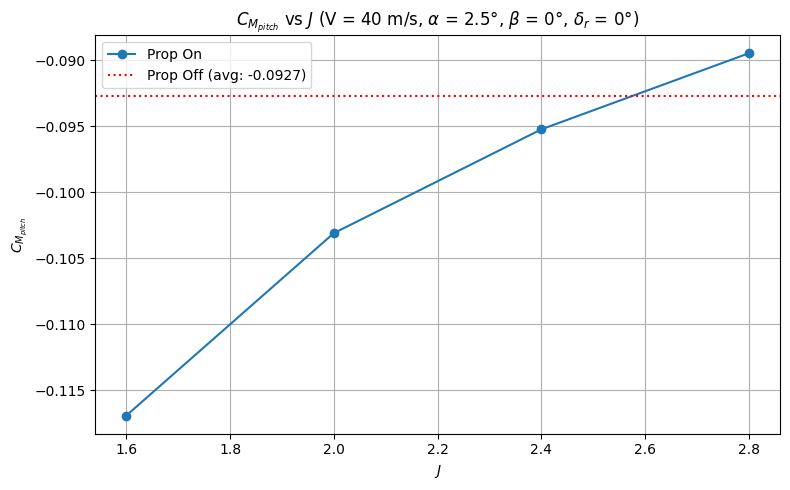

Saved to plot_images/CMpitch_vs_J_V40_AoS0_AoA2.5_rudder0.png


In [ ]:
import matplotlib.pyplot as plt

# Filter prop on
df_on_j = df[
    (df["V_round"] == 40) & 
    (df["AoA_round"] == 2.5) &
    (df["AoS_round"] == 0) &
    (df["dR"] == 0)
].sort_values("J_round")

# Filter prop off and average
df_off_j = df_prop_off[
    (df_prop_off["V_round"] == 40) & 
    (df_prop_off["AoA_round"] == 2.5) &
    (df_prop_off["AoS_round"] == 0) &
    (df_prop_off["dR"] == 0) &
    (df_prop_off["dE"] == 0)
]

cmpitch_off_avg = df_off_j["CMpitch_FINAL"].mean() if not df_off_j.empty else None

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    df_on_j["J_round"],
    df_on_j["CMpitch_FINAL"],
    marker="o",
    linestyle="-",
    label="Prop On"
)

if cmpitch_off_avg is not None:
    ax.axhline(
        y=cmpitch_off_avg, 
        color='r', 
        linestyle=':', 
        label=f"Prop Off (avg: {cmpitch_off_avg:.4f})"
    )

ax.set_xlabel(r"$J \, (\frac{1}{\Pi_3 \cdot \Pi_4})$")
ax.set_ylabel(r"$C_{M_{pitch}} \, (2 \cdot \frac{\Pi_B}{\Pi_6})$")
ax.set_title(r"$C_{M_{pitch}} \, (2 \cdot \frac{\Pi_B}{\Pi_6})$ vs $J \, (\frac{1}{\Pi_3 \cdot \Pi_4})$ (V = 40 m/s, $\alpha$ = 2.5°, $\beta$ = 0°, $\delta_r$ = 0°)")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig("plot_images/CMpitch_vs_J_V40_AoS0_AoA2.5_rudder0.png", dpi=150)
plt.show()
print("Saved to plot_images/CMpitch_vs_J_V40_AoS0_AoA2.5_rudder0.png")